In [9]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
GPU available: True


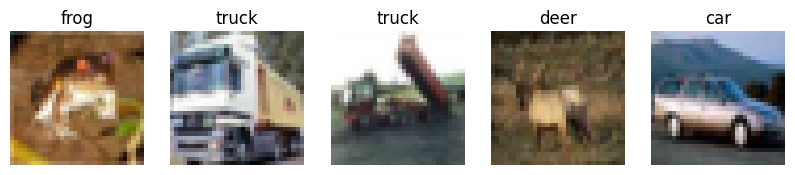

In [10]:
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

fig, axes = plt.subplots(1, 5, figsize=(10,2))
for i in range(5):
    img, label = trainset[i]
    axes[i].imshow(img.permute(1,2,0))
    axes[i].set_title(classes[label])
    axes[i].axis('off')
plt.show()

In [12]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

batch_size = 128
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)
print("Data ready")

Data ready


In [13]:
class ResNet18_CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        base = torchvision.models.resnet18(weights=None, num_classes=num_classes)
        base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()
        self.model = base

    def forward(self, x):
        return self.model(x)

model_final = ResNet18_CIFAR().to(device)
print(model_final)

ResNet18_CIFAR(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
       

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer_final = optim.Adam(model_final.parameters(), lr=0.001)

for epoch in range(20):
    model_final.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer_final.zero_grad()
        outputs = model_final(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_final.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.3f}")

Epoch 1, Loss: 1.356
Epoch 2, Loss: 0.851
Epoch 3, Loss: 0.665
Epoch 4, Loss: 0.567
Epoch 5, Loss: 0.497
Epoch 6, Loss: 0.438
Epoch 7, Loss: 0.398
Epoch 8, Loss: 0.360
Epoch 9, Loss: 0.324
Epoch 10, Loss: 0.304
Epoch 11, Loss: 0.279
Epoch 12, Loss: 0.257
Epoch 13, Loss: 0.239
Epoch 14, Loss: 0.225
Epoch 15, Loss: 0.209
Epoch 16, Loss: 0.195
Epoch 17, Loss: 0.180
Epoch 18, Loss: 0.167
Epoch 19, Loss: 0.153
Epoch 20, Loss: 0.144


In [15]:
model_final.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_final(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

baseline_final = 100 * correct / total
print(f"Baseline accuracy (CIFAR-adapted ResNet18): {baseline_final:.2f}%")

Baseline accuracy (CIFAR-adapted ResNet18): 89.68%


In [16]:
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    min_vals = ((0 - torch.tensor(mean)) / torch.tensor(std)).view(1,3,1,1).to(image.device)
    max_vals = ((1 - torch.tensor(mean)) / torch.tensor(std)).view(1,3,1,1).to(image.device)
    perturbed_image = torch.max(torch.min(perturbed_image, max_vals), min_vals)
    return perturbed_image

def pgd_attack(model, images, labels, epsilon, alpha, iters):
    min_vals = ((0 - torch.tensor(mean)) / torch.tensor(std)).view(1,3,1,1).to(images.device)
    max_vals = ((1 - torch.tensor(mean)) / torch.tensor(std)).view(1,3,1,1).to(images.device)
    original_images = images.clone().detach()
    perturbed = original_images + torch.empty_like(original_images).uniform_(-epsilon, epsilon)
    perturbed = torch.max(torch.min(perturbed, max_vals), min_vals)
    for i in range(iters):
        perturbed.requires_grad = True
        outputs = model(perturbed)
        loss = criterion(outputs, labels)
        model.zero_grad()
        loss.backward()
        data_grad = perturbed.grad.data
        perturbed = perturbed.detach() + alpha * data_grad.sign()
        eta = torch.clamp(perturbed - original_images, min=-epsilon, max=epsilon)
        perturbed = (original_images + eta).detach()
        perturbed = torch.max(torch.min(perturbed, max_vals), min_vals)
    return perturbed

epsilon = 0.03
alpha = 0.007
iters = 10

# FGSM
correct_fgsm = 0
total_fgsm = 0
for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    images.requires_grad = True
    outputs = model_final(images)
    loss = criterion(outputs, labels)
    model_final.zero_grad()
    loss.backward()
    data_grad = images.grad.data
    perturbed_images = fgsm_attack(images, epsilon, data_grad)
    outputs_attacked = model_final(perturbed_images)
    _, predicted_attacked = torch.max(outputs_attacked, 1)
    total_fgsm += labels.size(0)
    correct_fgsm += (predicted_attacked == labels).sum().item()
fgsm_final = 100 * correct_fgsm / total_fgsm

# PGD
correct_pgd = 0
total_pgd = 0
for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    perturbed = pgd_attack(model_final, images, labels, epsilon, alpha, iters)
    outputs = model_final(perturbed)
    _, predicted = torch.max(outputs, 1)
    total_pgd += labels.size(0)
    correct_pgd += (predicted == labels).sum().item()
pgd_final = 100 * correct_pgd / total_pgd

print(f"Final Model - Baseline: {baseline_final:.2f}% | FGSM: {fgsm_final:.2f}% | PGD: {pgd_final:.2f}%")

Final Model - Baseline: 89.68% | FGSM: 26.80% | PGD: 8.57%


In [18]:
import torch.nn.functional as F

def fgsm_attack_train(model, images, labels, epsilon):
    images = images.clone().detach().to(device)
    images.requires_grad = True
    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    perturbed = images + epsilon * images.grad.sign()
    min_vals = ((0 - torch.tensor(mean)) / torch.tensor(std)).view(1,3,1,1).to(images.device)
    max_vals = ((1 - torch.tensor(mean)) / torch.tensor(std)).view(1,3,1,1).to(images.device)
    perturbed = torch.max(torch.min(perturbed, max_vals), min_vals)
    return perturbed.detach()

model_defended_final = ResNet18_CIFAR().to(device)
optimizer_defended = optim.Adam(model_defended_final.parameters(), lr=0.001)

for epoch in range(20):
    model_defended_final.train()
    total_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        adv_images = fgsm_attack_train(model_defended_final, images, labels, epsilon)
        combined_images = torch.cat([images, adv_images], dim=0)
        combined_labels = torch.cat([labels, labels], dim=0)
        optimizer_defended.zero_grad()
        outputs = model_defended_final(combined_images)
        loss = criterion(outputs, combined_labels)
        loss.backward()
        optimizer_defended.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/20 - Loss: {total_loss/len(trainloader):.4f}")

Epoch 1/20 - Loss: 1.6254
Epoch 2/20 - Loss: 1.2309
Epoch 3/20 - Loss: 1.0275
Epoch 4/20 - Loss: 0.9016
Epoch 5/20 - Loss: 0.8144
Epoch 6/20 - Loss: 0.7496
Epoch 7/20 - Loss: 0.6933
Epoch 8/20 - Loss: 0.6502
Epoch 9/20 - Loss: 0.6117
Epoch 10/20 - Loss: 0.5732
Epoch 11/20 - Loss: 0.5434
Epoch 12/20 - Loss: 0.5137
Epoch 13/20 - Loss: 0.4850
Epoch 14/20 - Loss: 0.4582
Epoch 15/20 - Loss: 0.4407
Epoch 16/20 - Loss: 0.4113
Epoch 17/20 - Loss: 0.3901
Epoch 18/20 - Loss: 0.3688
Epoch 19/20 - Loss: 0.3468
Epoch 20/20 - Loss: 0.3328


In [19]:
model_defended_final.eval()

# Baseline
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_defended_final(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
baseline_defended_final = 100 * correct / total

# FGSM
correct_fgsm = 0
total_fgsm = 0
for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    images.requires_grad = True
    outputs = model_defended_final(images)
    loss = criterion(outputs, labels)
    model_defended_final.zero_grad()
    loss.backward()
    data_grad = images.grad.data
    perturbed_images = fgsm_attack(images, epsilon, data_grad)
    outputs_attacked = model_defended_final(perturbed_images)
    _, predicted_attacked = torch.max(outputs_attacked, 1)
    total_fgsm += labels.size(0)
    correct_fgsm += (predicted_attacked == labels).sum().item()
fgsm_defended_final = 100 * correct_fgsm / total_fgsm

# PGD
correct_pgd = 0
total_pgd = 0
for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    perturbed = pgd_attack(model_defended_final, images, labels, epsilon, alpha, iters)
    outputs = model_defended_final(perturbed)
    _, predicted = torch.max(outputs, 1)
    total_pgd += labels.size(0)
    correct_pgd += (predicted == labels).sum().item()
pgd_defended_final = 100 * correct_pgd / total_pgd

print(f"Defended (adapted arch) - Baseline: {baseline_defended_final:.2f}% | FGSM: {fgsm_defended_final:.2f}% | PGD: {pgd_defended_final:.2f}%")
print(f"Undefended (adapted arch) - Baseline: {baseline_final:.2f}% | FGSM: {fgsm_final:.2f}% | PGD: {pgd_final:.2f}%")

Defended (adapted arch) - Baseline: 89.37% | FGSM: 73.97% | PGD: 72.54%
Undefended (adapted arch) - Baseline: 89.68% | FGSM: 26.80% | PGD: 8.57%


In [20]:
def pgd_attack_strong(model, images, labels, epsilon, alpha, iters=40):
    min_vals = ((0 - torch.tensor(mean)) / torch.tensor(std)).view(1,3,1,1).to(images.device)
    max_vals = ((1 - torch.tensor(mean)) / torch.tensor(std)).view(1,3,1,1).to(images.device)
    original_images = images.clone().detach()
    perturbed = original_images + torch.empty_like(original_images).uniform_(-epsilon, epsilon)
    perturbed = torch.max(torch.min(perturbed, max_vals), min_vals)
    for i in range(iters):
        perturbed.requires_grad = True
        outputs = model(perturbed)
        loss = criterion(outputs, labels)
        model.zero_grad()
        loss.backward()
        data_grad = perturbed.grad.data
        perturbed = perturbed.detach() + alpha * data_grad.sign()
        eta = torch.clamp(perturbed - original_images, min=-epsilon, max=epsilon)
        perturbed = (original_images + eta).detach()
        perturbed = torch.max(torch.min(perturbed, max_vals), min_vals)
    return perturbed

correct_pgd40 = 0
total_pgd40 = 0
for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    perturbed = pgd_attack_strong(model_defended_final, images, labels, epsilon, alpha, iters=40)
    outputs = model_defended_final(perturbed)
    _, predicted = torch.max(outputs, 1)
    total_pgd40 += labels.size(0)
    correct_pgd40 += (predicted == labels).sum().item()
pgd40_defended = 100 * correct_pgd40 / total_pgd40

print(f"Defended model, PGD-40: {pgd40_defended:.2f}%")

Defended model, PGD-40: 72.25%


In [21]:
correct_transfer = 0
total_transfer = 0
for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    # Generate attack using UNDEFENDED model's gradients
    perturbed = pgd_attack(model_final, images, labels, epsilon, alpha, iters)
    # Test on DEFENDED model
    outputs = model_defended_final(perturbed)
    _, predicted = torch.max(outputs, 1)
    total_transfer += labels.size(0)
    correct_transfer += (predicted == labels).sum().item()
transfer_acc = 100 * correct_transfer / total_transfer

print(f"Defended model under transfer attack (from undefended model): {transfer_acc:.2f}%")

Defended model under transfer attack (from undefended model): 87.38%


In [22]:
from collections import defaultdict

def per_class_accuracy(model, testloader, attack_fn=None, **attack_kwargs):
    model.eval()
    correct = defaultdict(int)
    total = defaultdict(int)
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        if attack_fn is not None:
            images = attack_fn(model, images, labels, **attack_kwargs)
        with torch.no_grad():
            outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for label, pred in zip(labels, predicted):
            total[label.item()] += 1
            correct[label.item()] += (pred == label).item()
    return {classes[i]: 100*correct[i]/total[i] for i in range(10)}

print("Undefended, PGD, per-class:")
print(per_class_accuracy(model_final, testloader, pgd_attack, epsilon=epsilon, alpha=alpha, iters=iters))
print("Defended, PGD, per-class:")
print(per_class_accuracy(model_defended_final, testloader, pgd_attack, epsilon=epsilon, alpha=alpha, iters=iters))

Undefended, PGD, per-class:
{'plane': 6.7, 'car': 19.3, 'bird': 4.7, 'cat': 0.9, 'deer': 2.0, 'dog': 1.7, 'frog': 6.8, 'horse': 18.0, 'ship': 11.7, 'truck': 14.2}
Defended, PGD, per-class:
{'plane': 77.8, 'car': 83.5, 'bird': 62.2, 'cat': 54.4, 'deer': 68.3, 'dog': 57.5, 'frog': 81.1, 'horse': 75.5, 'ship': 77.5, 'truck': 87.9}


In [23]:
import numpy as np

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seeds = [0, 1]
undefended_results = []

for seed in seeds:
    set_seed(seed)
    model_seed = ResNet18_CIFAR().to(device)
    optimizer_seed = optim.Adam(model_seed.parameters(), lr=0.001)
    for epoch in range(20):
        model_seed.train()
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer_seed.zero_grad()
            loss = criterion(model_seed(images), labels)
            loss.backward()
            optimizer_seed.step()
    model_seed.eval()

    correct = total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            _, pred = torch.max(model_seed(images), 1)
            total += labels.size(0); correct += (pred==labels).sum().item()
    baseline = 100*correct/total

    correct_fgsm = total_fgsm = 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        images.requires_grad = True
        outputs = model_seed(images)
        loss = criterion(outputs, labels)
        model_seed.zero_grad()
        loss.backward()
        data_grad = images.grad.data
        perturbed_images = fgsm_attack(images, epsilon, data_grad)
        outputs_attacked = model_seed(perturbed_images)
        _, predicted_attacked = torch.max(outputs_attacked, 1)
        total_fgsm += labels.size(0)
        correct_fgsm += (predicted_attacked == labels).sum().item()
    fgsm_acc = 100 * correct_fgsm / total_fgsm

    correct_pgd = total_pgd = 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        perturbed = pgd_attack(model_seed, images, labels, epsilon, alpha, iters)
        outputs = model_seed(perturbed)
        _, predicted = torch.max(outputs, 1)
        total_pgd += labels.size(0)
        correct_pgd += (predicted == labels).sum().item()
    pgd_acc = 100 * correct_pgd / total_pgd

    print(f"Seed {seed} - Baseline: {baseline:.2f}% | FGSM: {fgsm_acc:.2f}% | PGD: {pgd_acc:.2f}%")
    undefended_results.append((baseline, fgsm_acc, pgd_acc))

arr = np.array(undefended_results)
print("Mean:", arr.mean(axis=0))
print("Std:", arr.std(axis=0))

Seed 0 - Baseline: 90.18% | FGSM: 24.79% | PGD: 7.35%
Seed 1 - Baseline: 89.35% | FGSM: 24.94% | PGD: 8.99%
Mean: [89.765 24.865  8.17 ]
Std: [0.415 0.075 0.82 ]


In [24]:
import time

model_pgd_defended = ResNet18_CIFAR().to(device)
optimizer_pgd = optim.Adam(model_pgd_defended.parameters(), lr=0.001)

start = time.time()
model_pgd_defended.train()
running_loss = 0.0
for images, labels in trainloader:
    images, labels = images.to(device), labels.to(device)
    adv_images = pgd_attack(model_pgd_defended, images, labels, epsilon, alpha, iters=7)
    combined_images = torch.cat([images, adv_images], dim=0)
    combined_labels = torch.cat([labels, labels], dim=0)
    optimizer_pgd.zero_grad()
    loss = criterion(model_pgd_defended(combined_images), combined_labels)
    loss.backward()
    optimizer_pgd.step()
    running_loss += loss.item()
elapsed = time.time() - start
print(f"Epoch 1, Loss: {running_loss/len(trainloader):.4f}, Time: {elapsed/60:.1f} min")

Epoch 1, Loss: 1.6380, Time: 6.3 min


In [25]:
for epoch in range(2, 13):
    model_pgd_defended.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        adv_images = pgd_attack(model_pgd_defended, images, labels, epsilon, alpha, iters=7)
        combined_images = torch.cat([images, adv_images], dim=0)
        combined_labels = torch.cat([labels, labels], dim=0)
        optimizer_pgd.zero_grad()
        loss = criterion(model_pgd_defended(combined_images), combined_labels)
        loss.backward()
        optimizer_pgd.step()
        running_loss += loss.item()
    print(f"Epoch {epoch}/12, Loss: {running_loss/len(trainloader):.4f}")

Epoch 2/12, Loss: 1.2422
Epoch 3/12, Loss: 1.0485
Epoch 4/12, Loss: 0.9244
Epoch 5/12, Loss: 0.8340
Epoch 6/12, Loss: 0.7622
Epoch 7/12, Loss: 0.7098
Epoch 8/12, Loss: 0.6626
Epoch 9/12, Loss: 0.6233
Epoch 10/12, Loss: 0.5821
Epoch 11/12, Loss: 0.5579
Epoch 12/12, Loss: 0.5244


In [26]:
model_pgd_defended.eval()

correct = total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_pgd_defended(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
baseline_pgd_defended = 100 * correct / total

correct_fgsm = total_fgsm = 0
for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    images.requires_grad = True
    outputs = model_pgd_defended(images)
    loss = criterion(outputs, labels)
    model_pgd_defended.zero_grad()
    loss.backward()
    data_grad = images.grad.data
    perturbed_images = fgsm_attack(images, epsilon, data_grad)
    outputs_attacked = model_pgd_defended(perturbed_images)
    _, predicted_attacked = torch.max(outputs_attacked, 1)
    total_fgsm += labels.size(0)
    correct_fgsm += (predicted_attacked == labels).sum().item()
fgsm_pgd_defended = 100 * correct_fgsm / total_fgsm

correct_pgd = total_pgd = 0
for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    perturbed = pgd_attack(model_pgd_defended, images, labels, epsilon, alpha, iters)
    outputs = model_pgd_defended(perturbed)
    _, predicted = torch.max(outputs, 1)
    total_pgd += labels.size(0)
    correct_pgd += (predicted == labels).sum().item()
pgd_pgd_defended = 100 * correct_pgd / total_pgd

print(f"PGD-Defended (12 epochs) - Baseline: {baseline_pgd_defended:.2f}% | FGSM: {fgsm_pgd_defended:.2f}% | PGD: {pgd_pgd_defended:.2f}%")
print(f"\nFULL COMPARISON:")
print(f"Undefended         - Baseline: 89.68% | FGSM: 26.80% | PGD: 8.57%")
print(f"FGSM-defended (20ep)- Baseline: 89.37% | FGSM: 73.97% | PGD: 72.54%")
print(f"PGD-defended (12ep) - Baseline: {baseline_pgd_defended:.2f}% | FGSM: {fgsm_pgd_defended:.2f}% | PGD: {pgd_pgd_defended:.2f}%")

PGD-Defended (12 epochs) - Baseline: 85.65% | FGSM: 69.22% | PGD: 68.35%

FULL COMPARISON:
Undefended         - Baseline: 89.68% | FGSM: 26.80% | PGD: 8.57%
FGSM-defended (20ep)- Baseline: 89.37% | FGSM: 73.97% | PGD: 72.54%
PGD-defended (12ep) - Baseline: 85.65% | FGSM: 69.22% | PGD: 68.35%
